# Processamento e Transformação de Imagens com OpenCV
Pontifícia Universidade Católica do Rio Grande do Sul – PUCRS Escola Politécnica

Disciplina: Introdução à Visão Computacional

Profª. Daniela Oliveira Ferreira do Amaral

Nome: Lucas Leuck de Oliveira

- Usei como referencia o: https://docs.opencv.org/3.4.20/d4/d1b/tutorial_histogram_equalization.html porém deixei comparativos do cálculo OpenCV com cálculo aprendido em aula, fazendo revisões pelos PDFs e já aproveitei pra adicionar coisas vistas em aula também.

Este notebook segue a estrutura sugerida:
1. Instalação de Bibliotecas
2. Ambiente de Desenvolvimento
3. Acesso ao(s) arquivo(s) do Drive
4. Histograma Escala de Cinza
5. Histograma RGB
6. Ruído
7. Binarização
8. Transformação Linear
9. Inversa
10. Transformação Não Linear
11. Alargamento
12. Equalização de Histograma
13. Compressão


## 1) Instalação de Bibliotecas

In [ ]:
# No Google Colab, opencv, numpy e matplotlib já vêm instalados
!pip install opencv-python-headless numpy matplotlib --quiet


## 2) Ambiente de Desenvolvimento

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# Função auxiliar para exibir imagens (OpenCV usa BGR, matplotlib usa RGB)
def show_img(img, title="Imagem", cmap=None):
    plt.figure(figsize=(6,6))
    if cmap is None and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_side_by_side(img1, img2, title1="Original", title2="Transformada", cmap=None):
    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    def to_rgb(im):
        if cmap == 'gray' or len(im.shape) == 2:
            return im
        return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    c = 'gray' if (cmap=='gray') else None
    ax[0].imshow(to_rgb(img1), cmap=c); ax[0].set_title(title1); ax[0].axis('off')
    ax[1].imshow(to_rgb(img2), cmap=c); ax[1].set_title(title2); ax[1].axis('off')
    plt.show()

print("Ambiente configurado com sucesso!")


Ambiente configurado com sucesso!


## 3) Acesso a(os) arquivo(s) do Drive

In [ ]:
#Montar o Google Drive (usada neste notebook)
from google.colab import drive
drive.mount('/content/drive')

caminho_imagem = '/content/drive/MyDrive/Colab Notebooks/Imagem para Processamento/Imagem_exercicio_ruido_histograma.jpg'

print("Caminho definido:", caminho_imagem)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Caminho definido: /content/drive/MyDrive/Colab Notebooks/Imagem para Processamento/Imagem_exercicio_ruido_histograma.jpg


Dimensões da imagem (altura, largura, canais): (480, 771, 3)


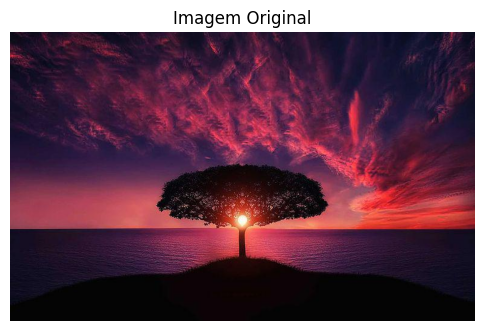

Tipo de dado: uint8  |  Bits por pixel: 8 por canal (24 bits no total, RGB)
L_max = 255  -> 256 níveis de intensidade


In [ ]:
# Carregar a imagem com OpenCV
img_original = cv2.imread(caminho_imagem)

if img_original is None:
    raise FileNotFoundError("Não foi possível carregar a imagem. Verifique o caminho/upload.")

print("Dimensões da imagem (altura, largura, canais):", img_original.shape)
show_img(img_original, "Imagem Original")

print(f"Tipo de dado: {img_original.dtype}  |  Bits por pixel: 8 por canal "
      f"({img_original.shape[2] * 8} bits no total, RGB)")
print(f"L_max = {np.iinfo(img_original.dtype).max}  -> {np.iinfo(img_original.dtype).max + 1} níveis de intensidade")

## 4) Histograma em Escala de Cinza
Convertendo a imagem para tons de cinza e calculando o histograma h(i), que representa
o número de ocorrências de cada nível de cinza i (0 a 255).

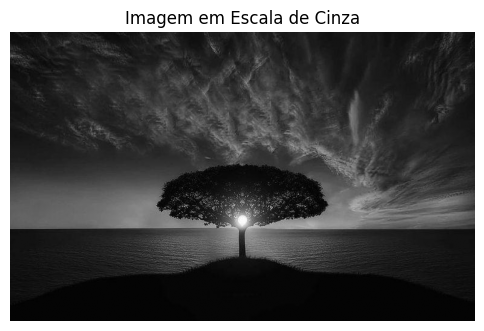

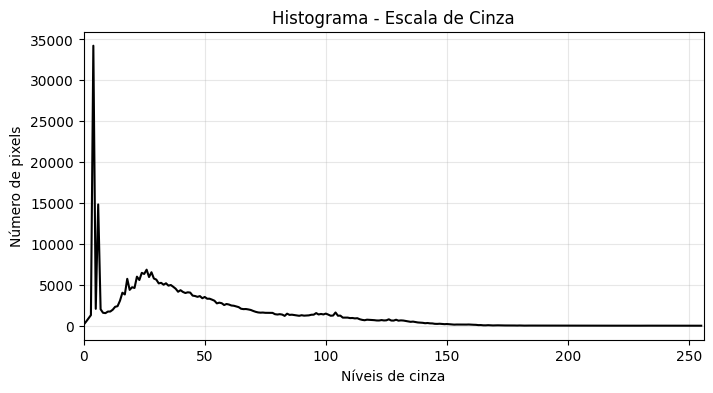

Total de pixels (nx × ny): 771 × 480 = 370080
Soma do histograma normalizado: 1.0000  (deve ser 1.0)
Nível de cinza mais frequente: 4 -> h(4) = 0.09249 (9.25% dos pixels)


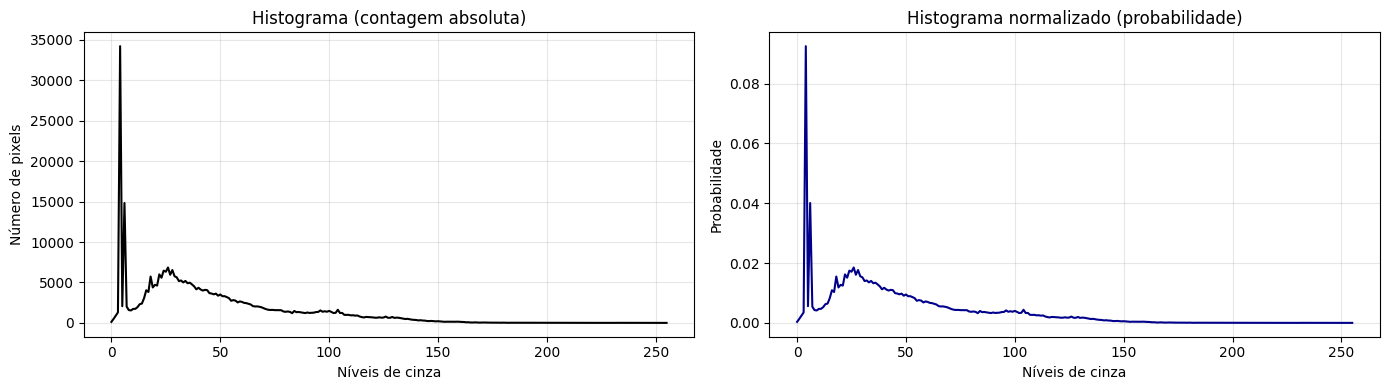

In [ ]:
img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

show_img(img_gray, "Imagem em Escala de Cinza", cmap='gray')

hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8,4))
plt.plot(hist_gray, color='black')
plt.title("Histograma - Escala de Cinza")
plt.xlabel("Níveis de cinza")
plt.ylabel("Número de pixels")
plt.xlim([0, 256])
plt.grid(alpha=0.3)
plt.show()

# Histograma normalizado: h(i) / (nx * ny)  -> distribuição de probabilidade
nx, ny = img_gray.shape[1], img_gray.shape[0]
total_pixels = nx * ny
hist_normalizado = hist_gray.ravel() / total_pixels

print(f"Total de pixels (nx × ny): {nx} × {ny} = {total_pixels}")
print(f"Soma do histograma normalizado: {hist_normalizado.sum():.4f}  (deve ser 1.0)")

nivel_exemplo = int(np.argmax(hist_normalizado))
print(f"Nível de cinza mais frequente: {nivel_exemplo} -> "
      f"h({nivel_exemplo}) = {hist_normalizado[nivel_exemplo]:.5f} "
      f"({hist_normalizado[nivel_exemplo]*100:.2f}% dos pixels)")

fig, ax = plt.subplots(1, 2, figsize=(14,4))
ax[0].plot(hist_gray, color='black'); ax[0].set_title("Histograma (contagem absoluta)")
ax[0].set_xlabel("Níveis de cinza"); ax[0].set_ylabel("Número de pixels"); ax[0].grid(alpha=0.3)
ax[1].plot(hist_normalizado, color='darkblue'); ax[1].set_title("Histograma normalizado (probabilidade)")
ax[1].set_xlabel("Níveis de cinza"); ax[1].set_ylabel("Probabilidade"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Medidas Estatísticas

In [ ]:
# Medidas estatísticas do histograma
media    = float(np.mean(img_gray))
desvio   = float(np.std(img_gray))
mediana  = float(np.median(img_gray))
modo     = int(np.argmax(hist_gray))
minimo   = int(np.min(img_gray))
maximo   = int(np.max(img_gray))
variancia= float(np.var(img_gray))
n_pixels = img_gray.size
perc_claros = float(np.sum(img_gray > 240) / n_pixels * 100)
perc_escuros= float(np.sum(img_gray < 15)  / n_pixels * 100)

print(f"Média:            {media:8.2f}   -> nível médio de luminosidade")
print(f"Desvio padrão:    {desvio:8.2f}   -> variação dos níveis (dispersão)")
print(f"Mediana:          {mediana:8.2f}   -> 50% dos pixels estão abaixo deste valor")
print(f"Modo:             {modo:8d}   -> nível de cinza mais frequente")
print(f"Variância:        {variancia:8.2f}")
print(f"Mínimo / Máximo:  {minimo:3d} / {maximo:3d}")
print(f"Total de pixels:  {n_pixels}")
print(f"Nível total:      255  (imagem de 8 bits)")
print(f"Percentual próximo do branco (>240): {perc_claros:.2f}%")
print(f"Percentual próximo do preto  (<15):  {perc_escuros:.2f}%")

Média:               45.75   -> nível médio de luminosidade
Desvio padrão:       35.91   -> variação dos níveis (dispersão)
Mediana:             36.00   -> 50% dos pixels estão abaixo deste valor
Modo:                    4   -> nível de cinza mais frequente
Variância:         1289.18
Mínimo / Máximo:    0 / 254
Total de pixels:  370080
Nível total:      255  (imagem de 8 bits)
Percentual próximo do branco (>240): 0.04%
Percentual próximo do preto  (<15):  18.69%


## 5) Histograma RGB
Calculando e plotando o histograma de cada canal de cor (R, G, B) separadamente,
como visto nos slides "Histogramas das Bandas de Cor".

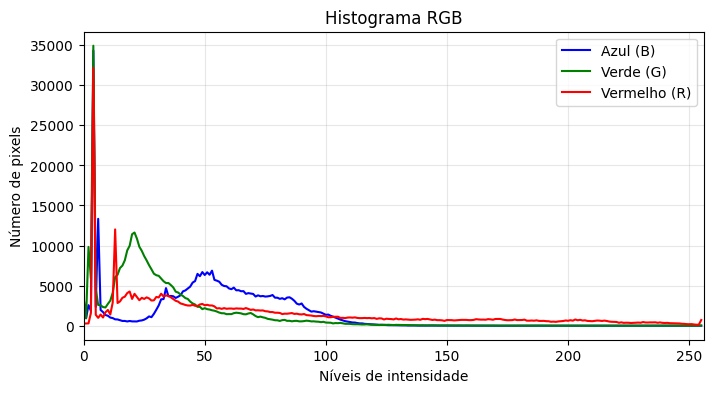

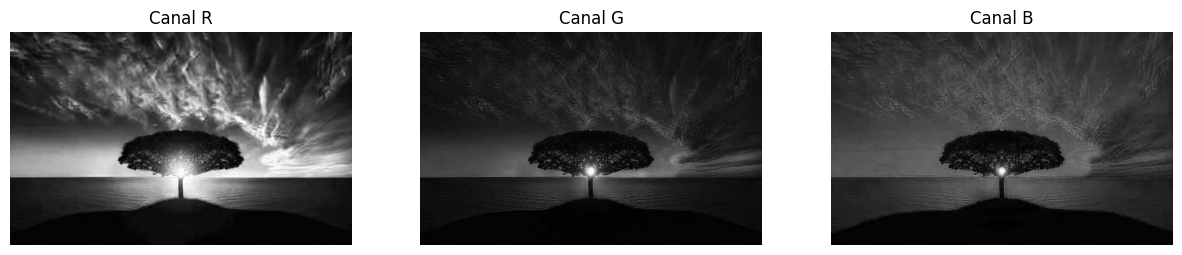

In [ ]:
cores = ('b', 'g', 'r')  # OpenCV carrega em BGR
nomes = ('Azul (B)', 'Verde (G)', 'Vermelho (R)')

plt.figure(figsize=(8,4))
for i, (c, nome) in enumerate(zip(cores, nomes)):
    hist = cv2.calcHist([img_original], [i], None, [256], [0, 256])
    plt.plot(hist, color=c, label=nome)

plt.title("Histograma RGB")
plt.xlabel("Níveis de intensidade")
plt.ylabel("Número de pixels")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

b, g, r = cv2.split(img_original)
fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(r, cmap='gray'); ax[0].set_title('Canal R'); ax[0].axis('off')
ax[1].imshow(g, cmap='gray'); ax[1].set_title('Canal G'); ax[1].axis('off')
ax[2].imshow(b, cmap='gray'); ax[2].set_title('Canal B'); ax[2].axis('off')
plt.show()


## 6) Ruído
Aplicando ruído **Gaussiano** e ruído **Sal e Pimenta (Salt & Pepper)** sobre a imagem em
escala de cinza, conforme discutido na aula de Ruído e Realce.

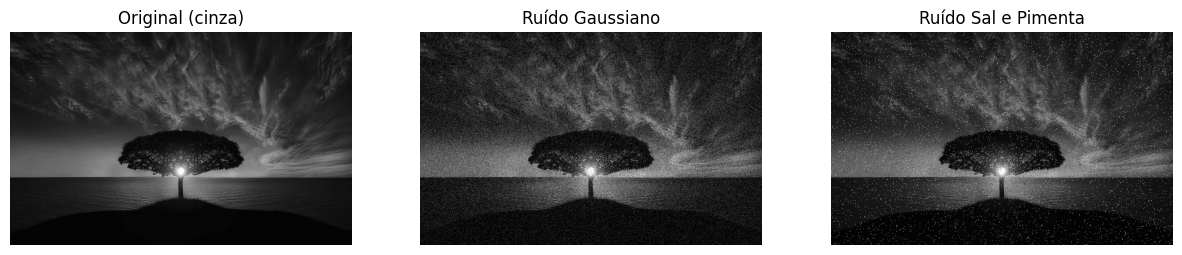

/tmp/ipykernel_4666/1260430823.py:31: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[0].hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
/tmp/ipykernel_4666/1260430823.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[0].hist(img_ruido_gauss.ravel(), 256, [0,256], alpha=0.5, label='Ruído Gaussiano')
/tmp/ipykernel_4666/1260430823.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[1].hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
/tmp/ipykernel_4666/1260430823.py:36: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; 

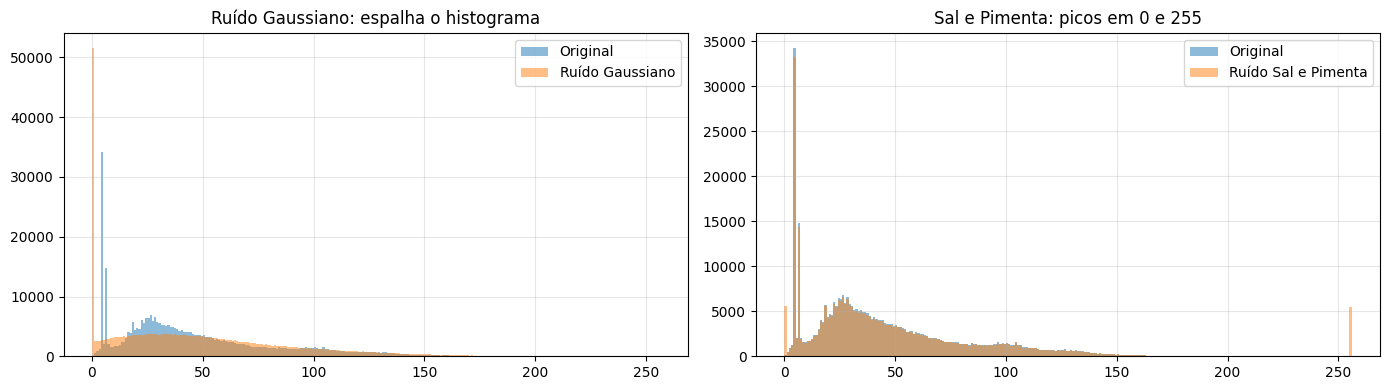

Pixels em 0 (pimenta)  — original:    127 | com ruído:   5635
Pixels em 255 (sal)    — original:      0 | com ruído:   5425


In [ ]:
def adicionar_ruido_gaussiano(img, media=0, desvio=25):
    ruido = np.random.normal(media, desvio, img.shape).astype(np.float32)
    img_ruidosa = img.astype(np.float32) + ruido
    img_ruidosa = np.clip(img_ruidosa, 0, 255).astype(np.uint8)
    return img_ruidosa

def adicionar_ruido_sal_pimenta(img, prob=0.02):
    img_ruidosa = img.copy()
    # Sal (branco)
    n_sal = int(prob/2 * img.size)
    coords = [np.random.randint(0, i, n_sal) for i in img.shape]
    img_ruidosa[tuple(coords)] = 255
    # Pimenta (preto)
    n_pimenta = int(prob/2 * img.size)
    coords = [np.random.randint(0, i, n_pimenta) for i in img.shape]
    img_ruidosa[tuple(coords)] = 0
    return img_ruidosa

img_ruido_gauss = adicionar_ruido_gaussiano(img_gray, media=0, desvio=25)
img_ruido_sp = adicionar_ruido_sal_pimenta(img_gray, prob=0.03)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title('Original (cinza)'); ax[0].axis('off')
ax[1].imshow(img_ruido_gauss, cmap='gray'); ax[1].set_title('Ruído Gaussiano'); ax[1].axis('off')
ax[2].imshow(img_ruido_sp, cmap='gray'); ax[2].set_title('Ruído Sal e Pimenta'); ax[2].axis('off')
plt.show()

# Histogramas comparativos
fig, ax = plt.subplots(1, 2, figsize=(14,4))

ax[0].hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
ax[0].hist(img_ruido_gauss.ravel(), 256, [0,256], alpha=0.5, label='Ruído Gaussiano')
ax[0].legend(); ax[0].set_title("Ruído Gaussiano: espalha o histograma"); ax[0].grid(alpha=0.3)

ax[1].hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
ax[1].hist(img_ruido_sp.ravel(), 256, [0,256], alpha=0.5, label='Ruído Sal e Pimenta')
ax[1].legend(); ax[1].set_title("Sal e Pimenta: picos em 0 e 255"); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Quantificando os picos
print(f"Pixels em 0 (pimenta)  — original: {np.sum(img_gray==0):6d} | com ruído: {np.sum(img_ruido_sp==0):6d}")
print(f"Pixels em 255 (sal)    — original: {np.sum(img_gray==255):6d} | com ruído: {np.sum(img_ruido_sp==255):6d}")


## 7) Binarização
Transformando a imagem em preto e branco puro usando um limiar (threshold) fixo e,
como comparação, o método automático de Otsu.

Limiar escolhido automaticamente pelo método de Otsu: 61.0


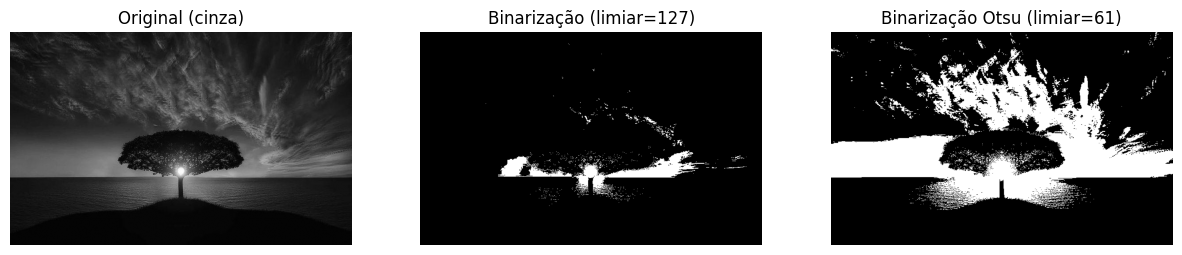

In [ ]:
# Threshold fixo
limiar = 127
_, img_bin_fixo = cv2.threshold(img_gray, limiar, 255, cv2.THRESH_BINARY)

# Threshold automático (Otsu)
otsu_val, img_bin_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Limiar escolhido automaticamente pelo método de Otsu: {otsu_val}")

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title('Original (cinza)'); ax[0].axis('off')
ax[1].imshow(img_bin_fixo, cmap='gray'); ax[1].set_title(f'Binarização (limiar={limiar})'); ax[1].axis('off')
ax[2].imshow(img_bin_otsu, cmap='gray'); ax[2].set_title(f'Binarização Otsu (limiar={int(otsu_val)})'); ax[2].axis('off')
plt.show()


## 8) Transformação Linear
Conforme a aula: $g = a \cdot f + b$

- **a**: controla o contraste (escala dos níveis de cinza)
- **b**: controla o brilho (deslocamento)

Usamos `cv2.convertScaleAbs`, que já aplica `alpha*f + beta` e satura os valores em [0,255].

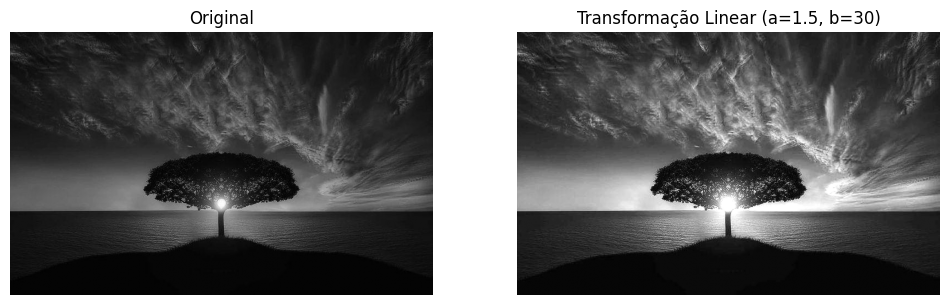

/tmp/ipykernel_4666/1860095304.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
/tmp/ipykernel_4666/1860095304.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_linear.ravel(), 256, [0,256], alpha=0.5, label='Transformada (linear)')


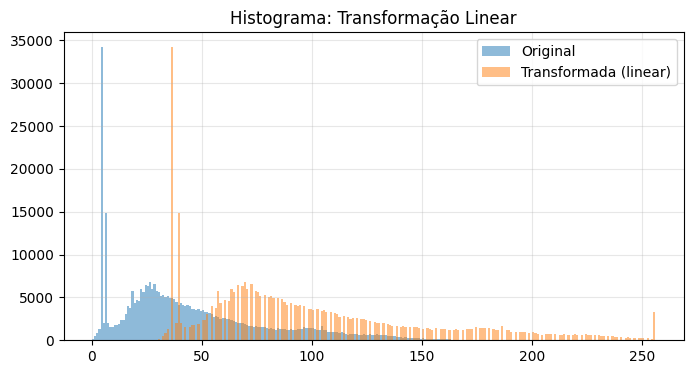

In [ ]:
a = 1.5   # contraste
b = 30    # brilho

img_linear = cv2.convertScaleAbs(img_gray, alpha=a, beta=b)

show_side_by_side(img_gray, img_linear,
                   title1="Original", title2=f"Transformação Linear (a={a}, b={b})",
                   cmap='gray')

plt.figure(figsize=(8,4))
plt.hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
plt.hist(img_linear.ravel(), 256, [0,256], alpha=0.5, label='Transformada (linear)')
plt.legend(); plt.title("Histograma: Transformação Linear"); plt.grid(alpha=0.3)
plt.show()


## 9) Transformação Inversa (Negativo)
$g = 255 - f$

Caso particular da transformação linear, com a = -1 e b = 255.

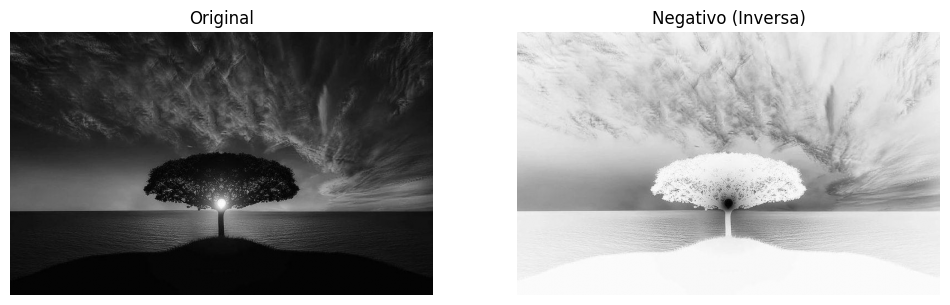

In [ ]:
img_negativo = 255 - img_gray

show_side_by_side(img_gray, img_negativo, title1="Original", title2="Negativo (Inversa)", cmap='gray')


## 10) Transformação Não Linear
Conforme visto em aula, aplicamos as funções:

- **Logarítmica:** $g = a \cdot \log(1+f)$, com $a = \dfrac{255}{\log(1+f_{max})}$
- **Exponencial:** $g = a \cdot (e^{f} - 1)$
- **Quadrado:** $g = a * f^2$
- **Raiz quadrada:** $g = a \cdot \sqrt{f}$

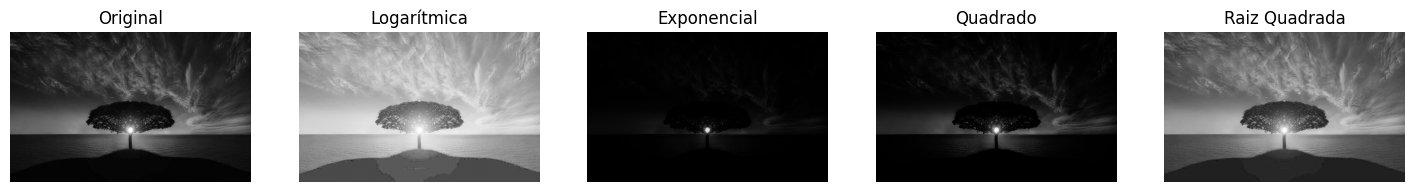

In [ ]:
img_float = img_gray.astype(np.float32)
f_max = np.max(img_float)

# Logarítmica
a_log = 255 / np.log(1 + f_max)
img_log = a_log * np.log(1 + img_float)
img_log = np.clip(img_log, 0, 255).astype(np.uint8)

# Exponencial: g = a * (e^(c*f) - 1), com normalização para [0,255]
c_exp = 0.02
img_exp = np.expm1(c_exp * img_float)          # e^(c*f) - 1
img_exp = img_exp * (255.0 / img_exp.max())    # normaliza
img_exp = np.clip(img_exp, 0, 255).astype(np.uint8)

# Quadrado: g = a * f²  (slide: aumenta contraste em regiões de média e alta intensidade)
a_quad = 255 / (f_max ** 2)
img_quad = np.clip(a_quad * (img_float ** 2), 0, 255).astype(np.uint8)

# Raiz Quadrada
a_sqrt = 255 / np.sqrt(f_max)
img_sqrt = a_sqrt * np.sqrt(img_float)
img_sqrt = np.clip(img_sqrt, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 5, figsize=(18,5))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(img_log, cmap='gray'); ax[1].set_title('Logarítmica'); ax[1].axis('off')
ax[2].imshow(img_exp, cmap='gray'); ax[2].set_title('Exponencial'); ax[2].axis('off')
ax[3].imshow(img_quad, cmap='gray'); ax[3].set_title('Quadrado'); ax[3].axis('off')
ax[4].imshow(img_sqrt, cmap='gray'); ax[4].set_title('Raiz Quadrada'); ax[4].axis('off')
plt.show()


## 11) Alargamento de Contraste (Contrast Stretching)
Estica os valores de intensidade da imagem para ocupar toda a faixa [0,255], melhorando o contraste.

Intensidade mínima: 0, máxima: 254
Diferença máxima entre fórmula da aula e cv2.normalize: 1 nível(is)


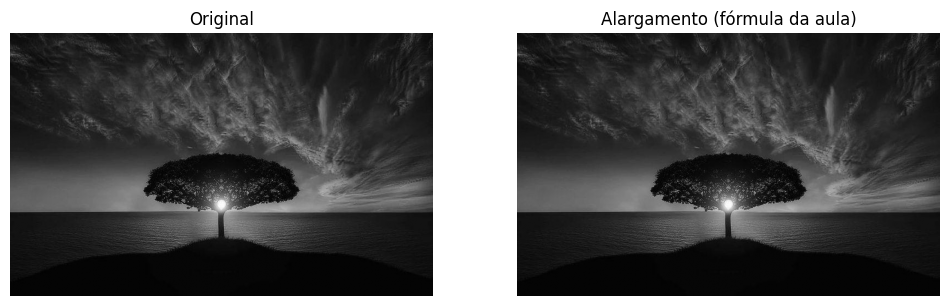

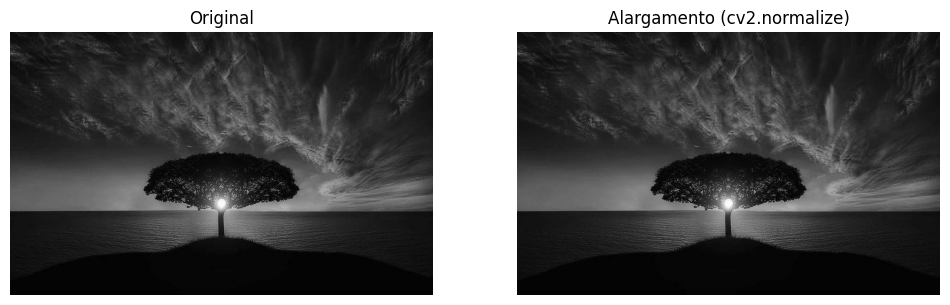

/tmp/ipykernel_4666/3170388473.py:19: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
/tmp/ipykernel_4666/3170388473.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_alargada.ravel(), 256, [0,256], alpha=0.5, label='Alargada (aula)')
/tmp/ipykernel_4666/3170388473.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_alargada_cv.ravel(), 256, [0,256], alpha=0.3, label='Alargada (cv2.normalize)')


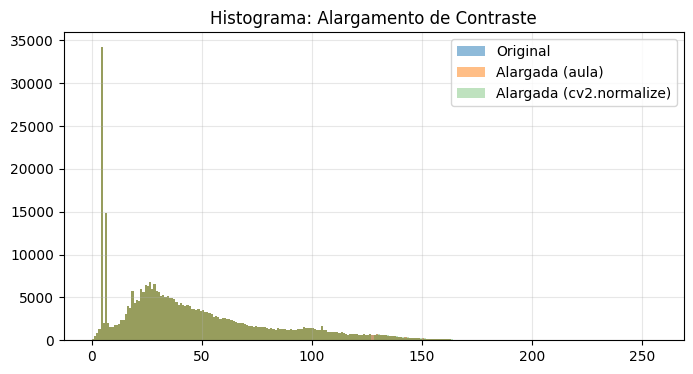

In [ ]:
f_min, f_max2 = np.min(img_gray), np.max(img_gray)
print(f"Intensidade mínima: {f_min}, máxima: {f_max2}")

# Fórmula da aula (alargamento linear min-max)
img_alargada = (img_gray.astype(np.float32) - f_min) * (255.0 / (f_max2 - f_min))
img_alargada = np.clip(img_alargada, 0, 255).astype(np.uint8)

# Equivalente usando cv2.normalize
img_alargada_cv = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)

# Comparando as duas implementações
dif_max = int(np.max(np.abs(img_alargada.astype(np.int16) - img_alargada_cv.astype(np.int16))))
print(f"Diferença máxima entre fórmula da aula e cv2.normalize: {dif_max} nível(is)")

show_side_by_side(img_gray, img_alargada, title1="Original", title2="Alargamento (fórmula da aula)", cmap='gray')
show_side_by_side(img_gray, img_alargada_cv, title1="Original", title2="Alargamento (cv2.normalize)", cmap='gray')

plt.figure(figsize=(8,4))
plt.hist(img_gray.ravel(), 256, [0,256], alpha=0.5, label='Original')
plt.hist(img_alargada.ravel(), 256, [0,256], alpha=0.5, label='Alargada (aula)')
plt.hist(img_alargada_cv.ravel(), 256, [0,256], alpha=0.3, label='Alargada (cv2.normalize)')
plt.legend(); plt.title("Histograma: Alargamento de Contraste"); plt.grid(alpha=0.3)
plt.show()

## 12) Equalização de Histograma
Baseado no tutorial oficial do OpenCV:
https://docs.opencv.org/3.4.20/d4/d1b/tutorial_histogram_equalization.html

A equalização redistribui os níveis de cinza usando a função de distribuição acumulada (CDF),
tornando o histograma mais uniforme e melhorando o contraste global, como visto no exemplo do gato nos slides.

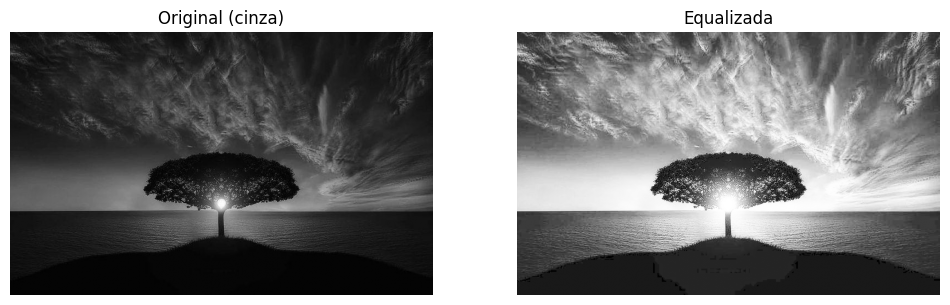

/tmp/ipykernel_4666/2504809019.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[0].hist(img_gray.ravel(), 256, [0,256], color='gray')
/tmp/ipykernel_4666/2504809019.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[1].hist(img_eq.ravel(), 256, [0,256], color='black')


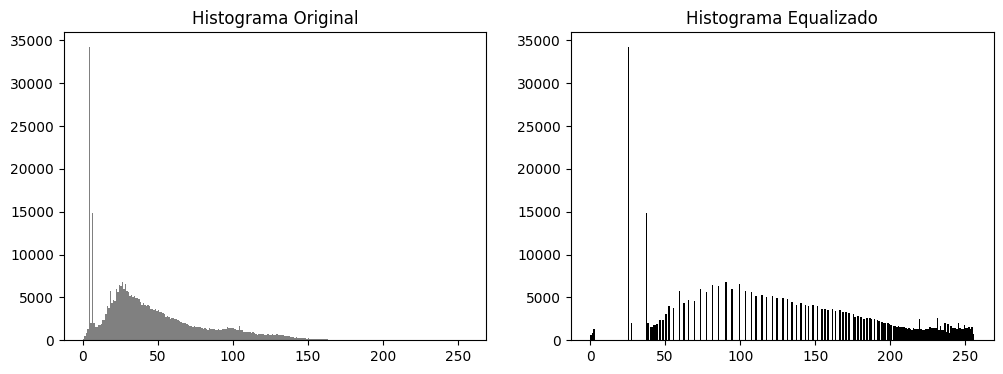

Diferença máxima entre a implementação da aula e cv2.equalizeHist: 1 nível(is)


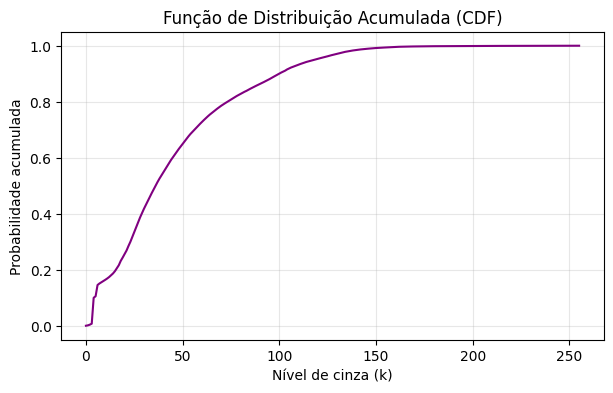

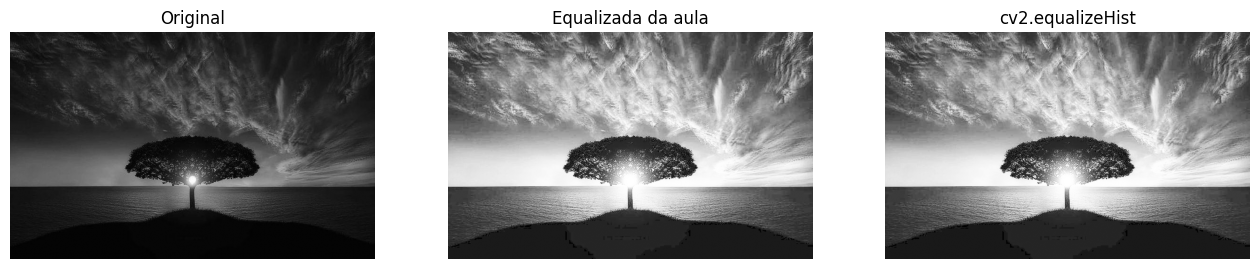

In [ ]:
# Equalização em escala de cinza (cv2.equalizeHist)
img_eq = cv2.equalizeHist(img_gray)

show_side_by_side(img_gray, img_eq, title1="Original (cinza)", title2="Equalizada", cmap='gray')

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(img_gray.ravel(), 256, [0,256], color='gray')
ax[0].set_title("Histograma Original")
ax[1].hist(img_eq.ravel(), 256, [0,256], color='black')
ax[1].set_title("Histograma Equalizado")
plt.show()

# Algoritmo da aula: g_k = round( CDF(f_k) * L_max )
hist_n = hist_gray.ravel() / img_gray.size      # 1-2: histograma normalizado
cdf = hist_n.cumsum()                            # 3-5: distribuição acumulada
tabela = np.round(cdf * 255).astype(np.uint8)    # 6-7: arredonda p/ nível mais próximo
img_eq_manual = tabela[img_gray]                 # 9: agrupa f_k para formar g_k

img_eq_cv = cv2.equalizeHist(img_gray)
dif_max = int(np.max(np.abs(img_eq_manual.astype(np.int16) - img_eq_cv.astype(np.int16))))
print(f"Diferença máxima entre a implementação da aula e cv2.equalizeHist: {dif_max} nível(is)")

plt.figure(figsize=(7,4))
plt.plot(cdf, color='purple')
plt.title("Função de Distribuição Acumulada (CDF)")
plt.xlabel("Nível de cinza (k)"); plt.ylabel("Probabilidade acumulada")
plt.grid(alpha=0.3); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16,5))
ax[0].imshow(img_gray, cmap='gray');       ax[0].set_title('Original');            ax[0].axis('off')
ax[1].imshow(img_eq_manual, cmap='gray');  ax[1].set_title('Equalizada da aula');  ax[1].axis('off')
ax[2].imshow(img_eq_cv, cmap='gray');      ax[2].set_title('cv2.equalizeHist');     ax[2].axis('off')
plt.show()

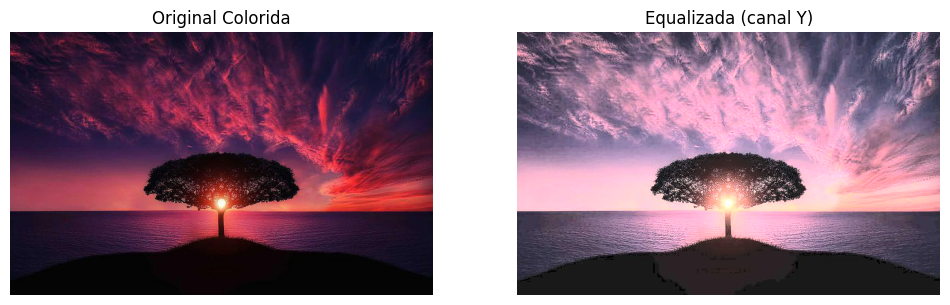

In [ ]:
# Equalização em imagem colorida (recomendação do tutorial OpenCV):
# equalizar apenas o canal de luminância (Y) no espaço YCrCb, preservando as cores originais
img_ycrcb = cv2.cvtColor(img_original, cv2.COLOR_BGR2YCrCb)
canais = cv2.split(img_ycrcb)
canais_lista = list(canais)
canais_lista[0] = cv2.equalizeHist(canais_lista[0])  # equaliza somente o canal Y (luminância)
img_ycrcb_eq = cv2.merge(canais_lista)
img_colorida_eq = cv2.cvtColor(img_ycrcb_eq, cv2.COLOR_YCrCb2BGR)

show_side_by_side(img_original, img_colorida_eq,
                   title1="Original Colorida", title2="Equalizada (canal Y)")


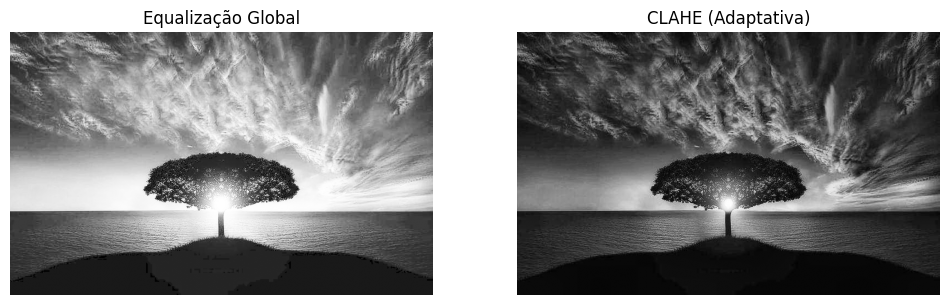

In [ ]:
# CLAHE (Contrast Limited Adaptive Histogram Equalization), também citado no tutorial do OpenCV como alternativa que evita super-amplificação de ruído

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_gray)

show_side_by_side(img_eq, img_clahe, title1="Equalização Global", title2="CLAHE (Adaptativa)", cmap='gray')


## 13) Compressão
Salvando a imagem em JPEG com diferentes níveis de qualidade e comparando tamanho de
arquivo x qualidade visual, como discutido no exemplo "PIX".

Arquivo original: 43.3 KB

Qualidade 100% ->   151.7 KB | taxa  0.29:1 | redução -250.6%
Qualidade  50% ->    34.7 KB | taxa  1.25:1 | redução   19.7%
Qualidade  20% ->    14.5 KB | taxa  2.98:1 | redução   66.5%
Qualidade   5% ->     7.5 KB | taxa  5.76:1 | redução   82.6%


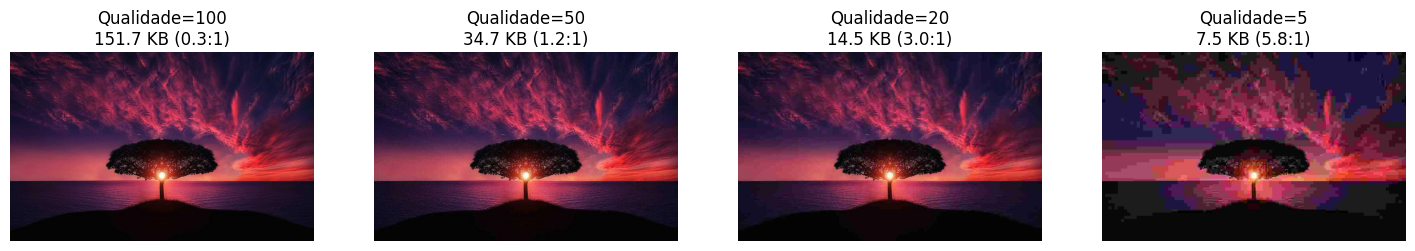

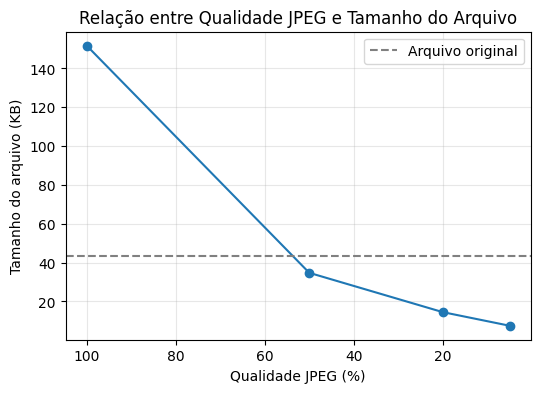

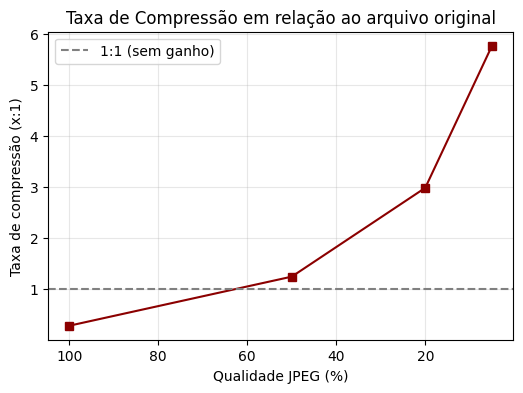

/tmp/ipykernel_4666/3072152989.py:57: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[0].hist(img_gray.ravel(), 256, [0,256], color='gray')
/tmp/ipykernel_4666/3072152989.py:59: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax[1].hist(img_q5.ravel(), 256, [0,256], color='darkred')


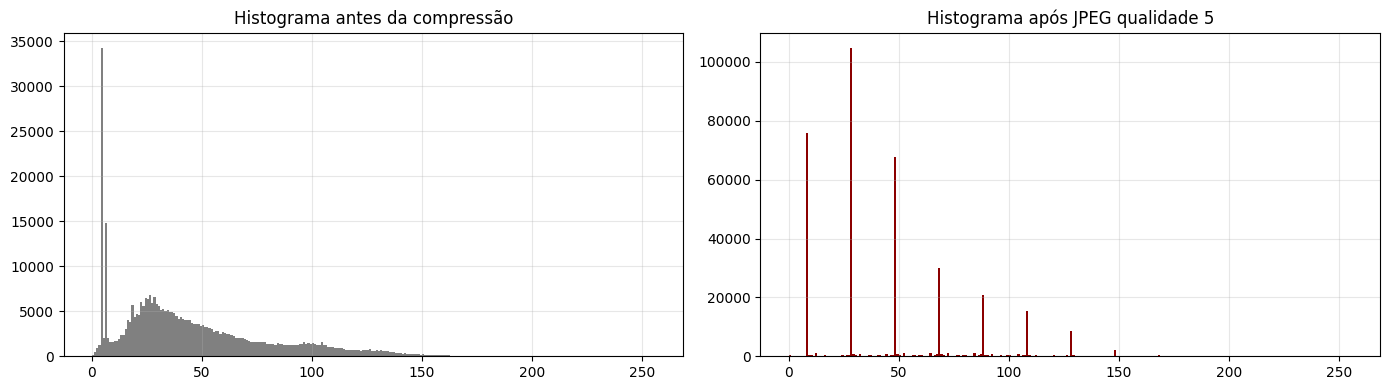

Níveis de cinza distintos — original: 254 | após JPEG q=5: 250


In [ ]:
# Tamanho do arquivo original no Drive (referência para a taxa de compressão)
tamanho_original_kb = os.path.getsize(caminho_imagem) / 1024
print(f"Arquivo original: {tamanho_original_kb:.1f} KB\n")

qualidades = [100, 50, 20, 5]
tamanhos = []
taxas = []

fig, ax = plt.subplots(1, len(qualidades), figsize=(18,5))

for i, q in enumerate(qualidades):
    nome_arquivo = f"compressao_q{q}.jpg"
    cv2.imwrite(nome_arquivo, img_original, [cv2.IMWRITE_JPEG_QUALITY, q])
    tamanho_kb = os.path.getsize(nome_arquivo) / 1024
    tamanhos.append(tamanho_kb)

    taxa = tamanho_original_kb / tamanho_kb
    reducao = (1 - tamanho_kb / tamanho_original_kb) * 100
    taxas.append(taxa)
    print(f"Qualidade {q:3d}% -> {tamanho_kb:7.1f} KB | taxa {taxa:5.2f}:1 | redução {reducao:6.1f}%")

    img_comprimida = cv2.imread(nome_arquivo)
    ax[i].imshow(cv2.cvtColor(img_comprimida, cv2.COLOR_BGR2RGB))
    ax[i].set_title(f"Qualidade={q}\n{tamanho_kb:.1f} KB ({taxa:.1f}:1)")
    ax[i].axis('off')

plt.show()

# Gráfico 1: qualidade x tamanho do arquivo
plt.figure(figsize=(6,4))
plt.plot(qualidades, tamanhos, marker='o')
plt.axhline(tamanho_original_kb, color='gray', linestyle='--', label='Arquivo original')
plt.gca().invert_xaxis()
plt.xlabel("Qualidade JPEG (%)")
plt.ylabel("Tamanho do arquivo (KB)")
plt.title("Relação entre Qualidade JPEG e Tamanho do Arquivo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfico 2: qualidade x taxa de compressão
plt.figure(figsize=(6,4))
plt.plot(qualidades, taxas, marker='s', color='darkred')
plt.axhline(1.0, color='gray', linestyle='--', label='1:1 (sem ganho)')
plt.gca().invert_xaxis()
plt.xlabel("Qualidade JPEG (%)")
plt.ylabel("Taxa de compressão (x:1)")
plt.title("Taxa de Compressão em relação ao arquivo original")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Efeito da compressão sobre o histograma (exemplo "PIX" da aula)
img_q5 = cv2.cvtColor(cv2.imread("compressao_q5.jpg"), cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(14,4))
ax[0].hist(img_gray.ravel(), 256, [0,256], color='gray')
ax[0].set_title("Histograma antes da compressão"); ax[0].grid(alpha=0.3)
ax[1].hist(img_q5.ravel(), 256, [0,256], color='darkred')
ax[1].set_title("Histograma após JPEG qualidade 5"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Níveis de cinza distintos — original: {len(np.unique(img_gray))} | "
      f"após JPEG q=5: {len(np.unique(img_q5))}")